In [1]:
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple

In [ ]:
def get_bands_data(filename: str) -> Tuple[np.ndarray, np.ndarray]:
    """Reads .bands.gnu file of QE"""
    data = np.loadtxt(filename)
    k = np.unique(data[:, 0])
    bands = np.reshape(data[:, 1], (-1, len(k)))
    return k , bands

In [13]:
k, bands = get_bands_data('ZnO_PBEplusU.bands.gnu')

In [25]:
np.linalg.norm([0.6666,  0.3333 , 0.0000])

0.7452814569006799

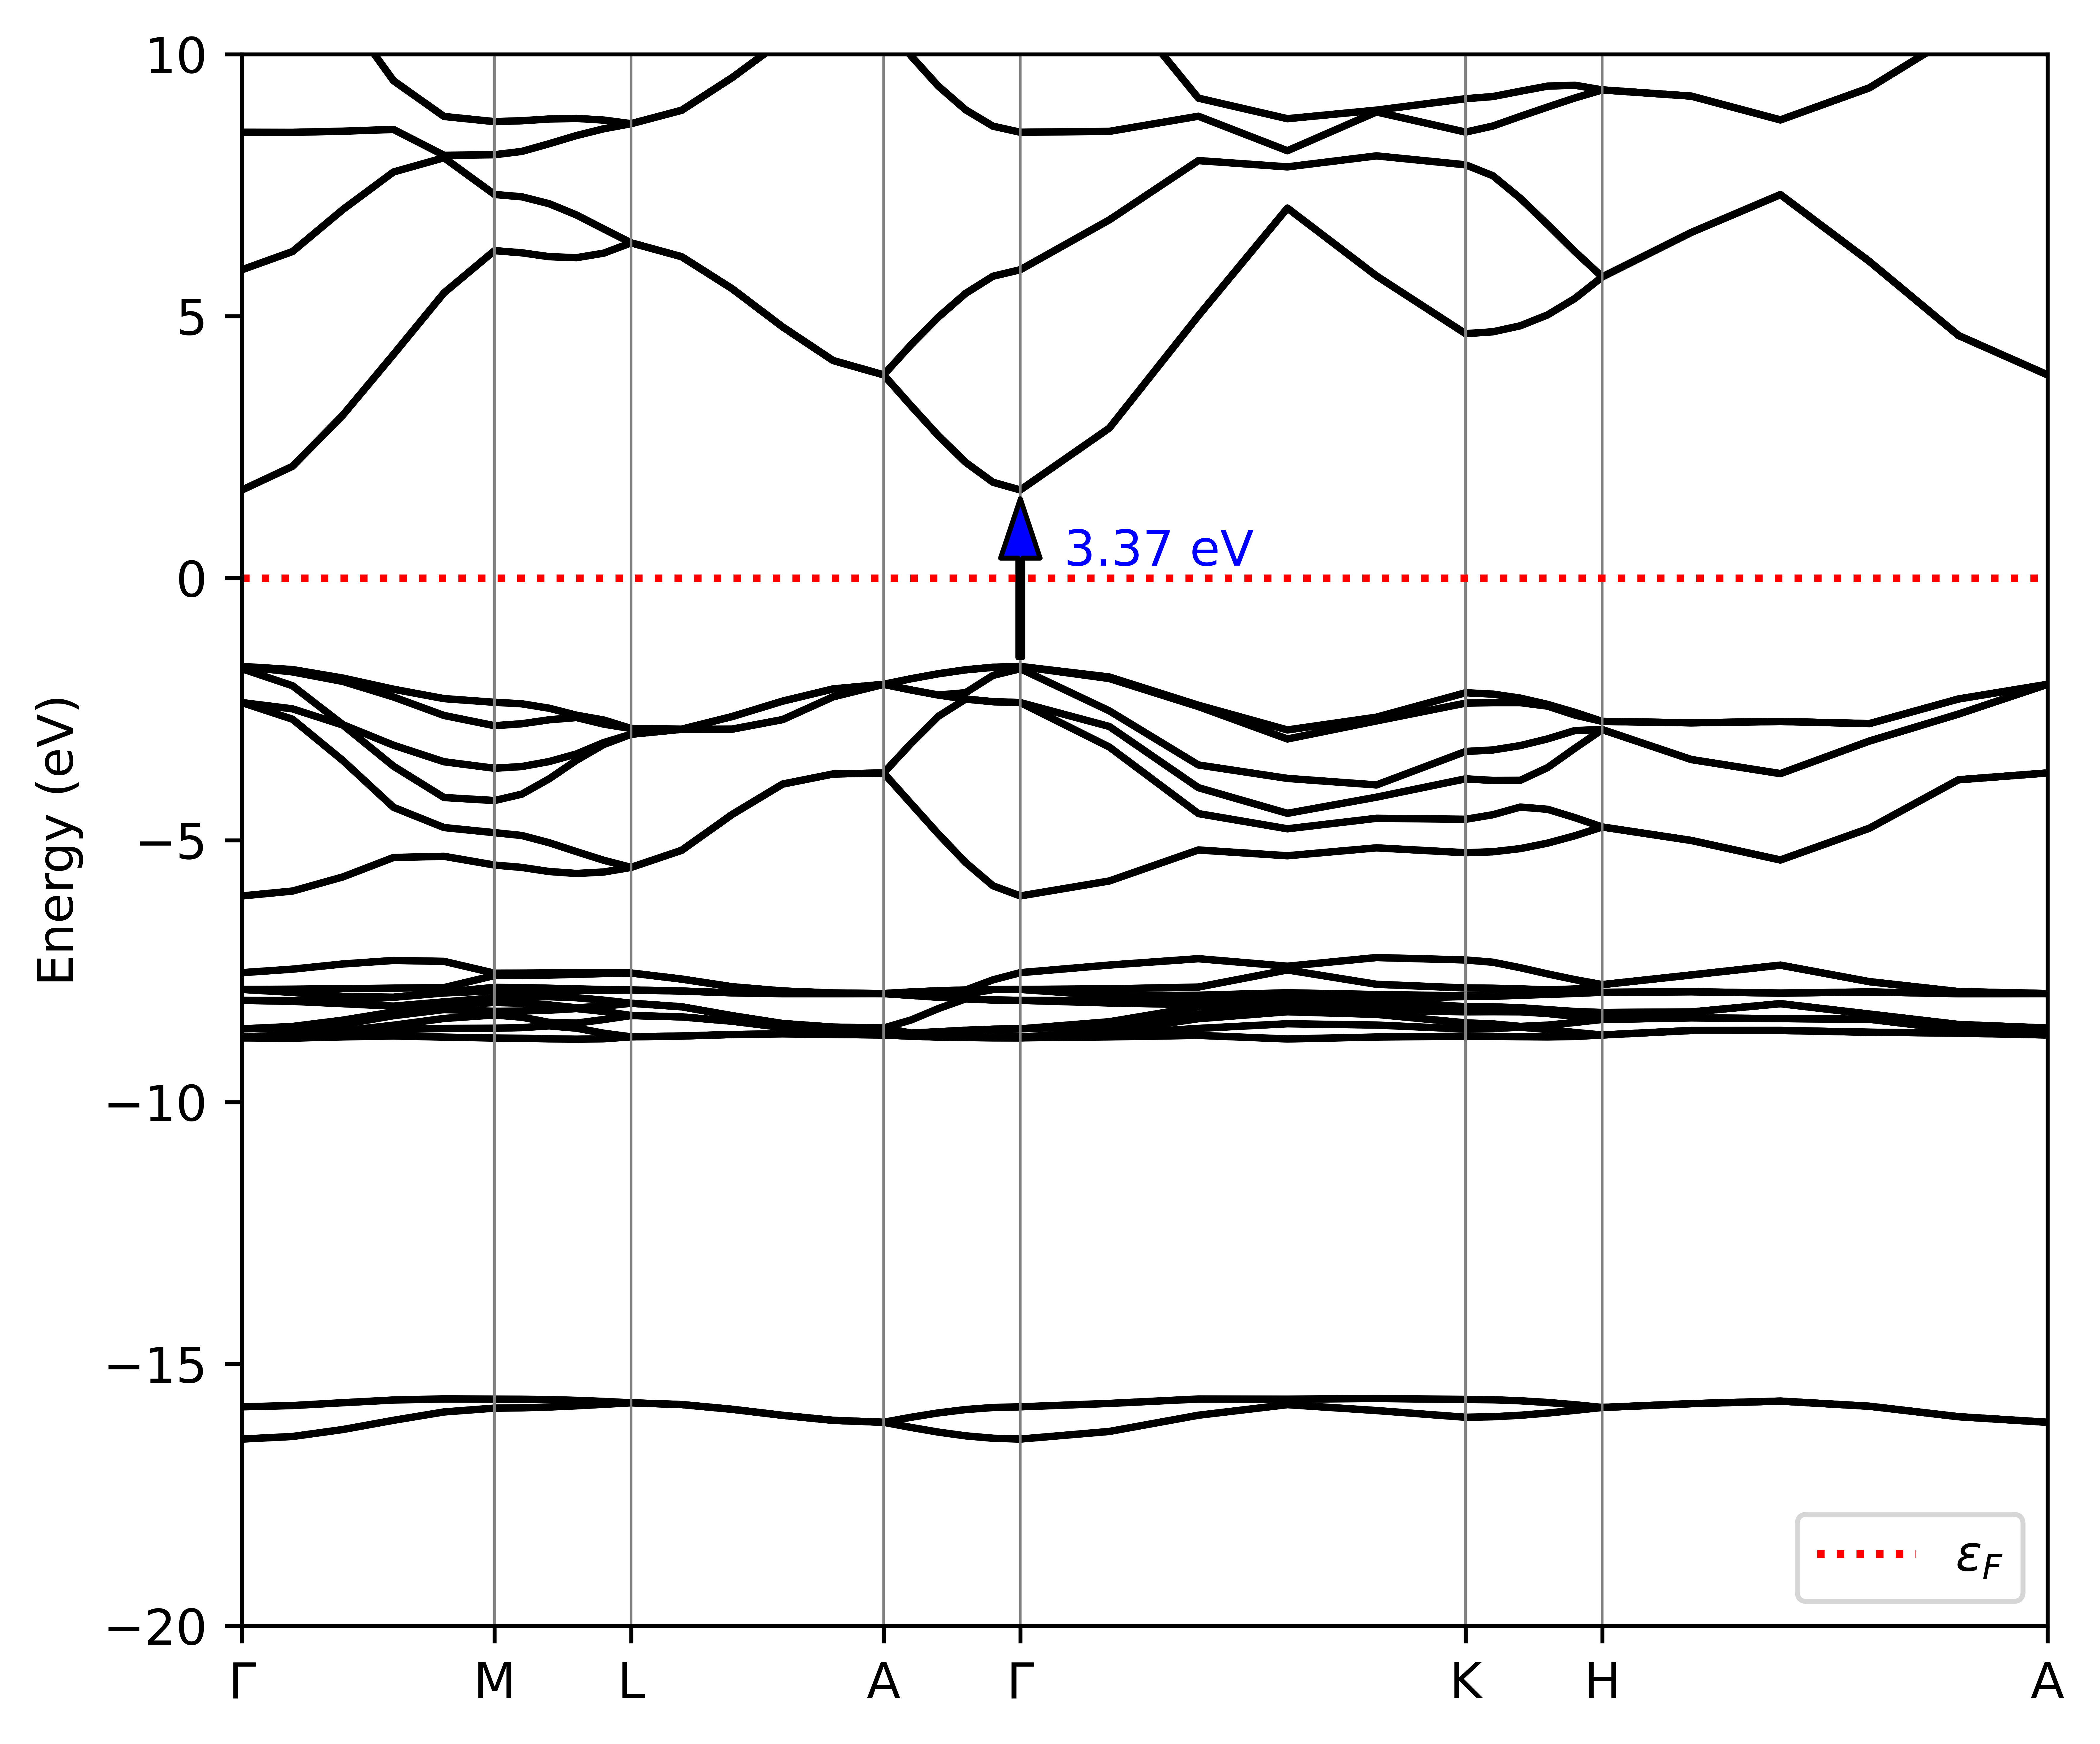

In [111]:
# Índices onde há pontos de alta simetria
labels = ['Γ', 'M', 'L', 'A', 'Γ', 'K', 'H', 'A']
sym_idx = [5*i for i in range(len(labels))]

min_conducao = bands[(bands > 6)].min()
max_valencia = bands[(bands < 6)].max() 
Efermi = (min_conducao+max_valencia) / 2
Egap = min_conducao - max_valencia

fig, ax = plt.subplots(figsize=(6,5), dpi=1200)

for i, band in enumerate( range(bands.shape[0]) ):
    ax.plot(k, bands[band,:  ]-Efermi, color='k')
ax.set_xlim(0, k.max())
ax.set_ylim(-7,8)


# Linhas verticais e rótulos
for i, x in enumerate(k[sym_idx]):
    ax.axvline(x, color='gray', lw=0.5)

ax.axhline(0, ls=':', c='red', label=r'${\epsilon}_F$')


ax.set_xticks(k[sym_idx])
ax.set_xticklabels(labels)

ax.set_yticks(range(-20,15,5))
# Add an arrow from max_valencia to min_conducao
arrow_x = k[20] # gG2
arrow_y_start = max_valencia - Efermi
arrow_y_end = min_conducao - Efermi
ax.annotate('', xy=(arrow_x, arrow_y_end), xytext=(arrow_x, arrow_y_start),
            arrowprops=dict(facecolor='blue', shrink=0.05, width=1, headwidth=8))
ax.text(arrow_x + 0.1, (arrow_y_start + arrow_y_end) / 2 + .5, f'{Egap:.2f} eV', color='blue', fontsize=10, va='center')
ax.set_ylabel('Energy (eV)')
fig.tight_layout()
ax.legend(loc='lower right')
plt.show()